# LLM-based classifier

In [1]:
!pip3 install -q transformers torch accelerate sentencepiece


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [95]:
# ============================================
# LLM-based Sentiment Classification Pipeline
# Clean, reusable, assignment-friendly version
# ============================================

import re
from typing import List, Dict, Tuple

import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tabulate import tabulate




# =========================================================
# Configuration
# =========================================================
MODEL_NAME = "google/flan-t5-small"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_INPUT_LENGTH = 512
MAX_NEW_TOKENS = 10

# =========================================================
# Load Data
# =========================================================
train_df = pd.read_csv('data/6/train.csv')

# =========================================================
# Prompt Templates
# =========================================================
PROMPT_TEMPLATES = {
    "prompt_1": """
    You are a text classification system.

    Classify the sentiment of the following text into exactly one label from:
    {labels}

    Return only one label.

    Text:
    {text}

    Label:
    """.strip(),

    "prompt_2": """
    Classify the sentiment of this text as one of these labels: {labels}.

    Text: {text}

    Answer with only one label.
    """.strip(),

        "prompt_3": """
    Read the text and predict its sentiment.

    Possible labels: {labels}

    Text:
    {text}

    Output only the correct label.
    """.strip(),

    "prompt_4": """
    You must perform sentiment classification.

    Allowed labels:
    {labels}

    Rules:
    - Choose one label only
    - Do not explain

    Text:
    {text}

    Sentiment:
    """.strip(),

    "prompt_5": """
    Determine whether the sentiment of the following text is:
    {labels}

    Text:
    {text}

    Return only the label.
    """.strip(),
    }


# =========================================================
# Model Loading
# =========================================================
def load_tokenizer(model_name: str):
    """Load and return the tokenizer for the selected model."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Some tokenizers may not define a pad token
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    return tokenizer


def load_model(model_name: str, device: str):
    """Load and return the seq2seq model on the target device."""
    dtype = torch.float16 if device == "cuda" else torch.float32

    model = AutoModelForSeq2SeqLM.from_pretrained(
        model_name,
        torch_dtype=dtype
    )
    model.to(device)
    model.eval()

    return model


# =========================================================
# Prompt Building
# =========================================================
def build_prompt(template: str, text: str, valid_labels: List[str]) -> str:
    """Create a formatted prompt for a single text sample."""
    label_text = ", ".join(valid_labels)
    return template.format(text=text, labels=label_text)


# =========================================================
# Text Preparation
# =========================================================
def prepare_model_inputs(
    tokenizer,
    prompt: str,
    device: str,
    max_input_length: int = MAX_INPUT_LENGTH
) -> Dict[str, torch.Tensor]:
    """Tokenize a prompt and move tensors to the target device."""
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_input_length
    )
    return {key: value.to(device) for key, value in inputs.items()}


# =========================================================
# Generation
# =========================================================
def generate_model_output(
    model,
    tokenizer,
    model_inputs: Dict[str, torch.Tensor],
    max_new_tokens: int = MAX_NEW_TOKENS
) -> str:
    """Generate raw text output from the model."""
    with torch.no_grad():
        output_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id
        )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()


# =========================================================
# Output Normalization
# =========================================================
def normalize_label(raw_output: str, valid_labels: List[str]) -> str:
    """
    Convert raw model output into one valid label.
    Returns 'UNKNOWN' if no valid label is detected.
    """
    cleaned_output = raw_output.strip().lower()
    normalized_labels = [label.lower() for label in valid_labels]

    # Exact match
    if cleaned_output in normalized_labels:
        return cleaned_output

    # Search for first valid label inside a longer response
    for label in normalized_labels:
        if re.search(rf"\b{re.escape(label)}\b", cleaned_output):
            return label

    return "UNKNOWN"


# =========================================================
# Single Prediction
# =========================================================
def predict_single_text(
    text: str,
    model,
    tokenizer,
    prompt_template: str,
    valid_labels: List[str],
    device: str
) -> Tuple[str, str, str]:
    """
    Predict sentiment for one text sample.

    Returns:
        prompt: formatted prompt
        raw_output: raw generated text
        predicted_label: normalized label
    """
    prompt = build_prompt(prompt_template, text, valid_labels)
    model_inputs = prepare_model_inputs(tokenizer, prompt, device)
    raw_output = generate_model_output(model, tokenizer, model_inputs)
    predicted_label = normalize_label(raw_output, valid_labels)

    return prompt, raw_output, predicted_label


# =========================================================
# Batch Prediction
# =========================================================
def predict_dataset(
    texts: List[str],
    model,
    tokenizer,
    prompt_template: str,
    valid_labels: List[str],
    device: str
) -> List[str]:
    """Predict labels for a list of texts using one prompt template."""
    predictions = []

    for text in texts:
        _, _, predicted_label = predict_single_text(
            text=text,
            model=model,
            tokenizer=tokenizer,
            prompt_template=prompt_template,
            valid_labels=valid_labels,
            device=device
        )
        predictions.append(predicted_label)

    return predictions


# =========================================================
# Multi-Prompt Prediction
# =========================================================
def predict_with_all_prompts(
    df: pd.DataFrame,
    text_column: str,
    model,
    tokenizer,
    prompt_templates: Dict[str, str],
    valid_labels: List[str],
    device: str
) -> pd.DataFrame:
    """
    Generate predictions for all prompt templates and
    return a copy of the dataframe with prediction columns added.
    """
    result_df = df.copy()

    for index, (_, template) in enumerate(prompt_templates.items(), start=1):
        column_name = f"out_label_Prompt_{index}"
        result_df[column_name] = predict_dataset(
            texts=result_df[text_column].tolist(),
            model=model,
            tokenizer=tokenizer,
            prompt_template=template,
            valid_labels=valid_labels,
            device=device
        )
        print(f"Finished predictions for {column_name}")

    return result_df


# =========================================================
# Example: Run Pipeline for One Sample
# =========================================================
def run_single_sample_demo(train_df: pd.DataFrame) -> None:
    """Run the full pipeline for one sample and print outputs."""
    valid_labels = sorted(train_df["sentiment"].astype(str).str.lower().unique().tolist())
    sample_text = str(train_df.loc[0, "text"])
    true_label = str(train_df.loc[0, "sentiment"]).lower()

    tokenizer = load_tokenizer(MODEL_NAME)
    model = load_model(MODEL_NAME, DEVICE)

    prompt, raw_output, predicted_label = predict_single_text(
        text=sample_text,
        model=model,
        tokenizer=tokenizer,
        prompt_template=PROMPT_TEMPLATES["prompt_1"],
        valid_labels=valid_labels,
        device=DEVICE
    )

    print("PROMPT:\n")
    print(prompt)
    print("\nRAW MODEL OUTPUT:", repr(raw_output))
    print("PREDICTED LABEL :", predicted_label)
    print("TRUE LABEL      :", true_label)
    print("CORRECT?        :", predicted_label == true_label)


# =========================================================
# Example: Run Pipeline for Whole Dataset
# =========================================================
def run_full_prompt_inference(
    input_df: pd.DataFrame,
    text_column: str = "text",
    label_column: str = "sentiment"
) -> pd.DataFrame:
    """
    Run all prompt templates on the full dataframe.
    Returns a dataframe containing prediction columns.
    """
    valid_labels = sorted(input_df[label_column].astype(str).str.lower().unique().tolist())

    tokenizer = load_tokenizer(MODEL_NAME)
    model = load_model(MODEL_NAME, DEVICE)

    output_df = predict_with_all_prompts(
        df=input_df,
        text_column=text_column,
        model=model,
        tokenizer=tokenizer,
        prompt_templates=PROMPT_TEMPLATES,
        valid_labels=valid_labels,
        device=DEVICE
    )

    return output_df

# =========================================================
# Save Results
# =========================================================
def save_results(predicted_df: pd.DataFrame, prompt_templates: Dict[str, str], base_dir: str = 'data/outputs') -> None:
    """
    Save the predicted dataframe and prompt templates to a new timestamped folder.

    Args:
        predicted_df (pd.DataFrame): DataFrame containing predictions.
        prompt_templates (Dict[str, str]): Dictionary of prompt templates.
        base_dir (str): Base directory where results will be saved.
    """
    # Create a new folder with an incremented number
    existing_folders = [int(folder) for folder in os.listdir(base_dir) if folder.isdigit()]
    next_folder = str(max(existing_folders) + 1) if existing_folders else '1'
    new_folder_path = os.path.join(base_dir, next_folder)
    os.makedirs(new_folder_path)

    # Save the predicted dataframe
    predicted_df.to_csv(os.path.join(new_folder_path, 'predicted_df.csv'), index=False)

    # Save the prompt templates
    pd.DataFrame.from_dict(prompt_templates, orient='index', columns=['Template']).to_csv(
        os.path.join(new_folder_path, 'PROMPT_TEMPLATES.csv')
    )

# =========================================================
# Evaluation
# =========================================================
def evaluation(
    df: pd.DataFrame,
    true_column_name: str,
    predicted_column_name: str,
    valid_labels: List[str],
    print_scores: bool = True,
    print_confusion_matrix: bool = False
) -> Dict[str, float]:
    """
    Calculate and optionally display the confusion matrix along with metrics.

    Args:
        df (pd.DataFrame): DataFrame containing true and predicted labels.
        true_column_name (str): Column name for true labels.
        predicted_column_name (str): Column name for predicted labels.
        valid_labels (List[str]): List of valid labels.
        print_score (bool): Whether to display the confusion matrix (default: True).

    Returns:
        Dict[str, float]: Dictionary containing metrics if print_score is False.
    """
    # Generate confusion matrix
    cm = confusion_matrix(df[true_column_name], df[predicted_column_name], labels=valid_labels)
    tn, fp, fn, tp = cm.ravel()

    # Calculate metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = precision_score(df[true_column_name], df[predicted_column_name], labels=valid_labels, average='binary', pos_label=valid_labels[0])
    recall = recall_score(df[true_column_name], df[predicted_column_name], labels=valid_labels, average='binary', pos_label=valid_labels[0])
    f1 = f1_score(df[true_column_name], df[predicted_column_name], labels=valid_labels, average='binary', pos_label=valid_labels[0])

    if print_scores:
        # Print metrics in a table format
        metrics_table = [
            ["Metric", "Value"],
            ["Accuracy", f"{accuracy:.4f}"],
            ["Precision", f"{precision:.4f}"],
            ["Recall", f"{recall:.4f}"],
            ["F1-score", f"{f1:.4f}"]
        ]
        print(tabulate(metrics_table, headers="firstrow", tablefmt="grid"))

    if print_confusion_matrix:
        # Display confusion matrix
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=valid_labels)
        disp.plot(cmap=plt.cm.Blues)
        plt.title("Confusion Matrix")
        plt.show()
    
    # Return metrics as a dictionary
    return {
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Accuracy": accuracy,
        "F1-score": f1,
        "Recall": recall,
        "Precision": precision
    }


# =========================================================
# Usage
# =========================================================
# Assumes train_df already exists and has:
# - train_df["text"]
# - train_df["sentiment"]

# 1) Run one-sample demo
# run_single_sample_demo(train_df)

# 2) Run full prompt inference
# predicted_df = run_full_prompt_inference(train_df)

# 3) Check prediction columns
# print(predicted_df.head())

In [ ]:
run_single_sample_demo(train_df)

PROMPT:

You are a text classification system.

    Classify the sentiment of the following text into exactly one label from:
    negative, positive

    Return only one label.

    Text:
    Best sock ever made. Consistent quality...I highly recommend Gold Toe  socks.

    Label:

RAW MODEL OUTPUT: 'positive'
PREDICTED LABEL : positive
TRUE LABEL      : positive
CORRECT?        : True


In [ ]:
# =========================================================
# Pipeline for full dataset inference with 1 prompt template
# =========================================================
# 1) Generate predictions 
predicted_df = run_full_prompt_inference(train_df)
# 2) Save predictions and templates
save_results(predicted_df, PROMPT_TEMPLATES)

Finished predictions for out_label_Prompt_1
Finished predictions for out_label_Prompt_2
Finished predictions for out_label_Prompt_3
Finished predictions for out_label_Prompt_4
Finished predictions for out_label_Prompt_5


+-----------+---------+
| Metric    |   Value |
+===========+=========+
| Accuracy  |  0.855  |
+-----------+---------+
| Precision |  0.5612 |
+-----------+---------+
| Recall    |  0.9116 |
+-----------+---------+
| F1-score  |  0.6947 |
+-----------+---------+


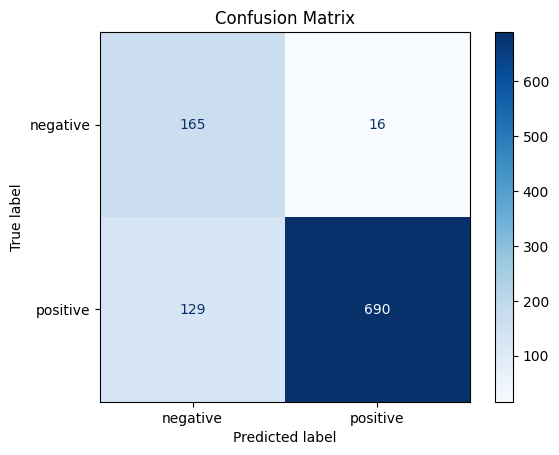

{'TP': np.int64(690),
 'TN': np.int64(165),
 'FP': np.int64(16),
 'FN': np.int64(129),
 'Accuracy': np.float64(0.855),
 'F1-score': 0.6947368421052632,
 'Recall': 0.9116022099447514,
 'Precision': 0.5612244897959183}

In [96]:
# 3) Evaluation
evaluation(predicted_df, true_column_name="sentiment", predicted_column_name="out_label_Prompt_1", valid_labels=sorted(train_df["sentiment"].astype(str).str.lower().unique().tolist()), print_scores=True, print_confusion_matrix=True)